In [25]:
pip install pandas numpy matplotlib seaborn scikit-learn jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
# Stage 1(Dataset Setup): Step-1
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# visualization style
sns.set(style="whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


In [27]:
# Stage 1(Dataset Setup): Step-2
# Load dataset

file_path = "../data/accepted_2007_to_2018Q4.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Dataset loaded successfully")

Dataset loaded successfully


In [28]:
# Stage 1(Dataset Setup): Step-3
# Check dataset size
df.shape

(2260701, 151)

In [29]:
# Stage 1(Dataset Setup): Step-4
# Preview the Data
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Stage 1(Dataset Setup): Step-5
# Check Column Names
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)

In [31]:
# Stage 1(Dataset Setup): Step-6
# Basic Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB


In [32]:
# Stage 2(Data Understanding): Step-1
# Identify Important Columns
important_columns = [
    'loan_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'dti',
    'delinq_2yrs',
    'revol_util',
    'total_acc',
    'application_type',
    'loan_status'
]

In [33]:
# Stage 2(Data Understanding): Step-2
# Create a New DataFrame with Only Important Columns
df = df[important_columns]
df.shape

(2260701, 17)

In [34]:
# Stage 2(Data Understanding): Step-3
# Preview the New DataFrame
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,revol_util,total_acc,application_type,loan_status
0,3600.0,36 months,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,29.7,13.0,Individual,Fully Paid
1,24700.0,36 months,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,19.2,38.0,Individual,Fully Paid
2,20000.0,60 months,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,56.2,18.0,Joint App,Fully Paid
3,35000.0,60 months,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,debt_consolidation,17.06,0.0,11.6,17.0,Individual,Current
4,10400.0,60 months,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,64.5,35.0,Individual,Fully Paid


In [35]:
# Stage 2(Data Understanding): Step-4
# Check New DataFrame Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Data columns (total 17 columns):
 #   Column               Dtype  
---  ------               -----  
 0   loan_amnt            float64
 1   term                 object 
 2   int_rate             float64
 3   installment          float64
 4   grade                object 
 5   sub_grade            object 
 6   emp_length           object 
 7   home_ownership       object 
 8   annual_inc           float64
 9   verification_status  object 
 10  purpose              object 
 11  dti                  float64
 12  delinq_2yrs          float64
 13  revol_util           float64
 14  total_acc            float64
 15  application_type     object 
 16  loan_status          object 
dtypes: float64(8), object(9)
memory usage: 293.2+ MB


In [36]:
# Stage 2(Data Understanding): Step-5
# Understand Loan Status
df['loan_status'].value_counts()

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

In [37]:
# Stage 3(Create Default Target Variable): Step-1
# Keep Only Relevant Status
df = df[df['loan_status'].isin(['Fully Paid','Charged Off','Default'])]

In [38]:
# Stage 3(Create Default Target Variable): Step-2
# Check Updated Loan Status Distribution
df['loan_status'].value_counts()

loan_status
Fully Paid     1076751
Charged Off     268559
Default             40
Name: count, dtype: int64

In [39]:
# Stage 3(Create Default Target Variable): Step-3
# Create Target Variable
df['default'] = df['loan_status'].apply(lambda x: 1 if x != 'Fully Paid' else 0)
df['default'].value_counts()

default
0    1076751
1     268599
Name: count, dtype: int64

In [45]:
# Stage 3(Create Default Target Variable): Step-4
# calculate the default rate
df['default'].mean()

0.19964990522912254

In [ ]:
# Stage 4 (Data Cleaning): Step-1
# Clean term
df['term'] = df['term'].astype(str).str.replace(' months', '').astype(int)
df['term'].head()

0    36
1    36
2    60
4    60
5    36
Name: term, dtype: int32

In [51]:
# Stage 4 (Data Cleaning): Step-2
# Clean int_rate
df['int_rate'] = df['int_rate'].astype(str).str.replace('%','').astype(float)
df['int_rate'].head()

0    13.99
1    11.99
2    10.78
4    22.45
5    13.44
Name: int_rate, dtype: float64

In [ ]:
# Stage 4 (Data Cleaning): Step-3
# Clean revol_util
df['revol_util'] = df['revol_util'].astype(str).str.replace('%','').astype(float)

In [52]:
df['emp_length'].unique()

array(['10+ years', '3 years', '4 years', '6 years', '7 years', '8 years',
       '2 years', '5 years', '9 years', '< 1 year', '1 year', nan],
      dtype=object)

In [67]:
# Stage 4 (Data Cleaning): Step-4
# Clean emp_length
# Reload only emp_length column from original file

temp_df = pd.read_csv("../data/accepted_2007_to_2018Q4.csv", 
                      usecols=['emp_length'],
                      low_memory=False)

# Replace the broken column
df['emp_length'] = temp_df['emp_length']
df['emp_length'].value_counts(dropna=False).head(10)

emp_length
10+ years    442209
2 years      121751
< 1 year     108065
3 years      107602
1 year        88495
5 years       84154
4 years       80558
NaN           78516
6 years       62735
8 years       60704
Name: count, dtype: int64

In [68]:
# Clean emp_length properly

df['emp_length'] = df['emp_length'].astype(str)

df['emp_length'] = df['emp_length'].str.extract('(\d+)')

df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

# Fix <1 year case (becomes 1 → set to 0)
df.loc[df['emp_length'] == 1, 'emp_length'] = 0
df['emp_length'].head()

0    10.0
1    10.0
2    10.0
4     3.0
5     4.0
Name: emp_length, dtype: float64

In [69]:
# Stage 4 (Data Cleaning): Step-5
# Check Missing Values
df.isnull().sum()

loan_amnt                  0
term                       0
int_rate                   0
installment                0
grade                      0
sub_grade                  0
emp_length             78516
home_ownership             0
annual_inc                 0
verification_status        0
purpose                    0
dti                        0
delinq_2yrs                0
revol_util                 0
total_acc                  0
application_type           0
loan_status                0
default                    0
dtype: int64

In [70]:
# Fill Missing Values
df['emp_length'].fillna(df['emp_length'].median(), inplace=True)
df['dti'].fillna(df['dti'].median(), inplace=True)
df['revol_util'].fillna(df['revol_util'].median(), inplace=True)
df.isnull().sum()

C:\Users\roshi\AppData\Local\Temp\ipykernel_1264\570390576.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['emp_length'].fillna(df['emp_length'].median(), inplace=True)
C:\Users\roshi\AppData\Local\Temp\ipykernel_1264\570390576.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

loan_amnt              0
term                   0
int_rate               0
installment            0
grade                  0
sub_grade              0
emp_length             0
home_ownership         0
annual_inc             0
verification_status    0
purpose                0
dti                    0
delinq_2yrs            0
revol_util             0
total_acc              0
application_type       0
loan_status            0
default                0
dtype: int64

**📊 EDA Structure**
1. Target Variable Analysis (Default Rate)
2. Univariate Analysis
3. Bivariate Analysis (MOST IMPORTANT)
4. Correlation Analysis

In [ ]:
# Stage 5 — Exploratory Data Analysis (EDA): Step-1
# Target Variable Analysis
df['default'].value_counts()

default
0    1076751
1     268599
Name: count, dtype: int64

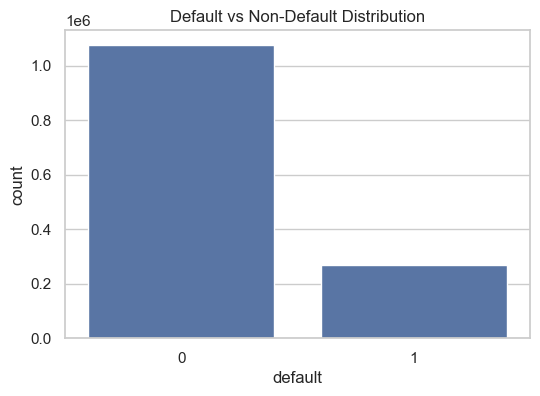

In [72]:
# 📊 Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df)
plt.title("Default vs Non-Default Distribution")
plt.show()

**Insights**
Majority of loans are non-default (~80%)

Around 20% loans are default

Dataset is slightly imbalanced

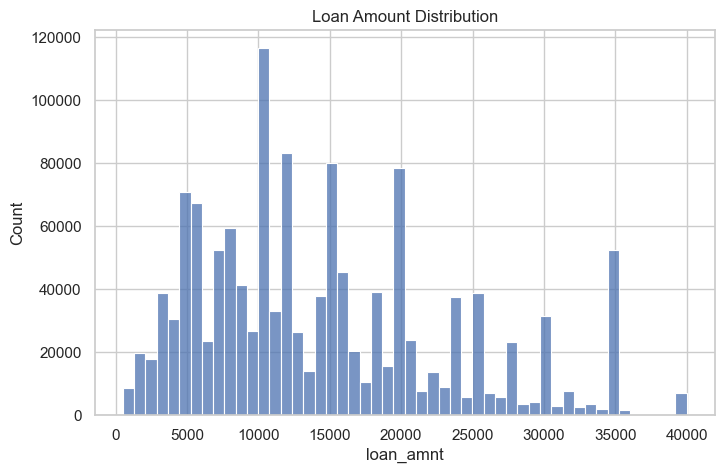

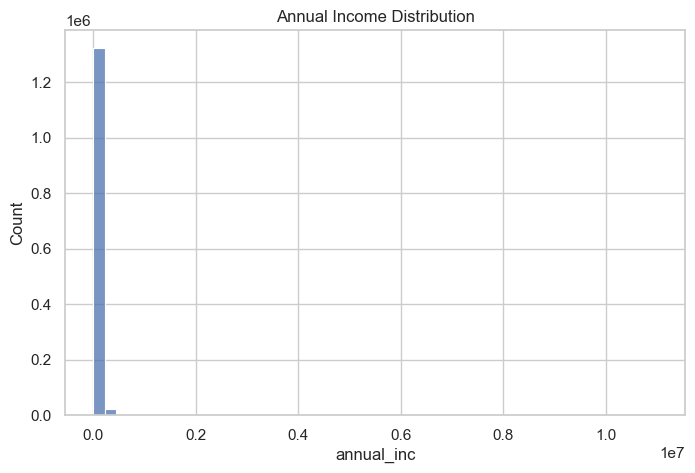

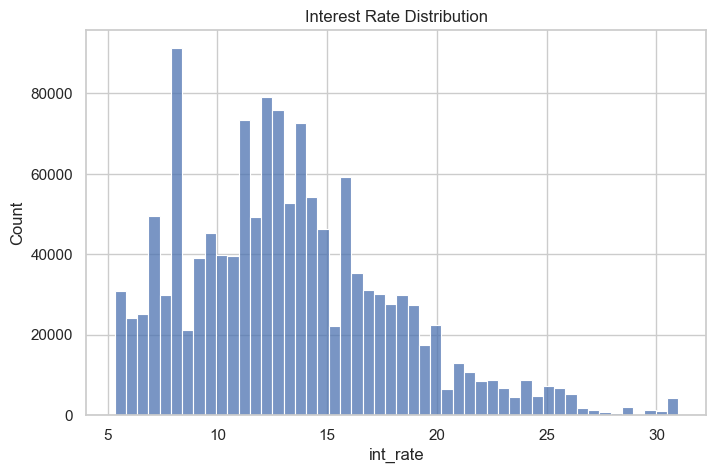

In [ ]:
# Stage 5 — Exploratory Data Analysis (EDA): Step-2
# Univariate Analysis

# Loan Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['loan_amnt'], bins=50)
plt.title("Loan Amount Distribution")
plt.show()

# Annual Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['annual_inc'], bins=50)
plt.title("Annual Income Distribution")
plt.show()

# Interest Rate Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['int_rate'], bins=50)
plt.title("Interest Rate Distribution")
plt.show()

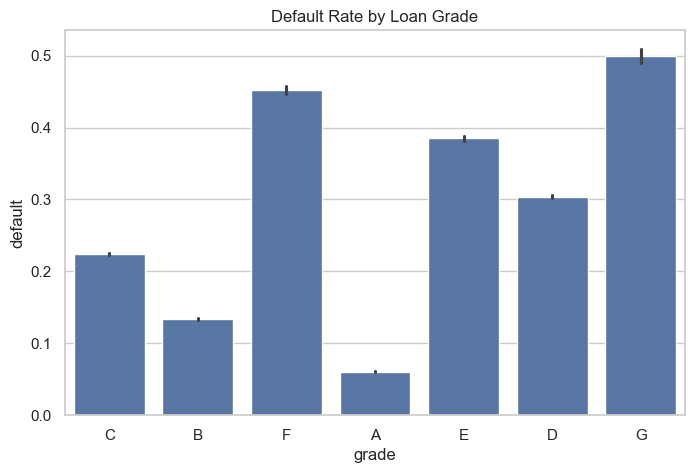

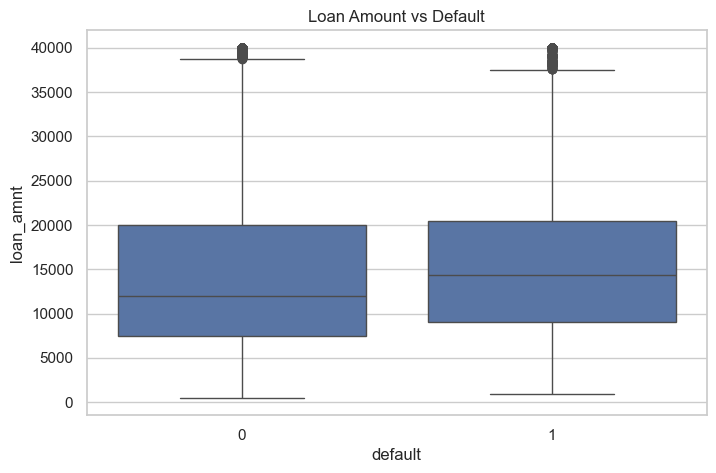

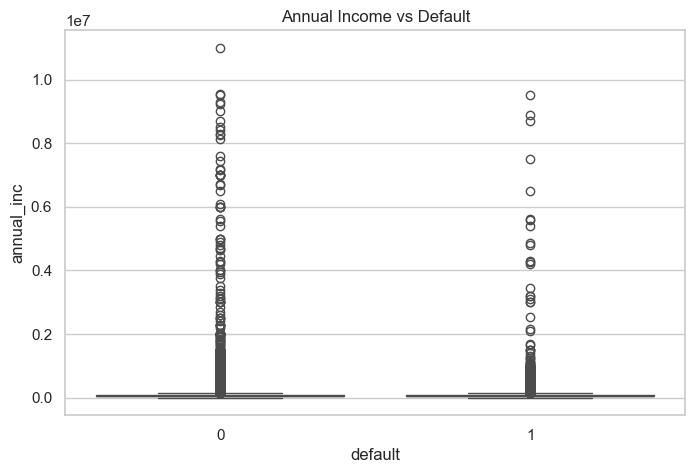

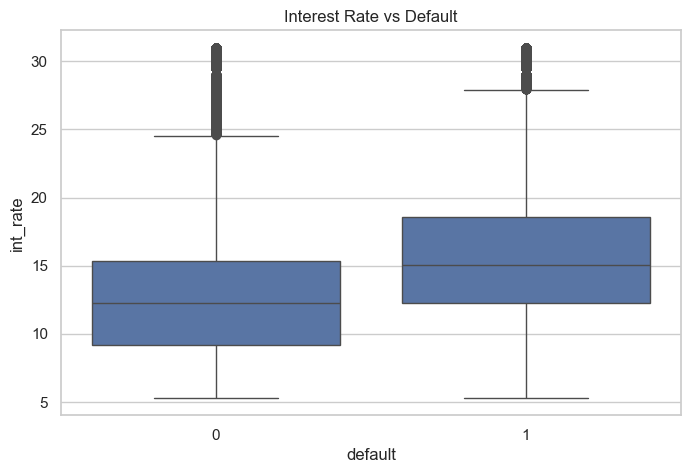

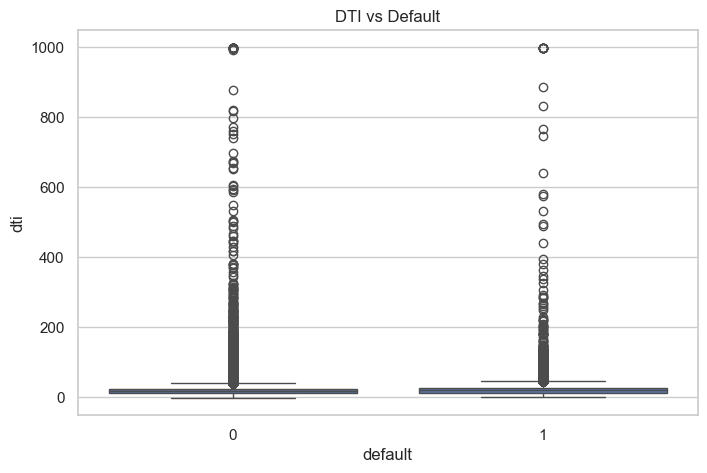

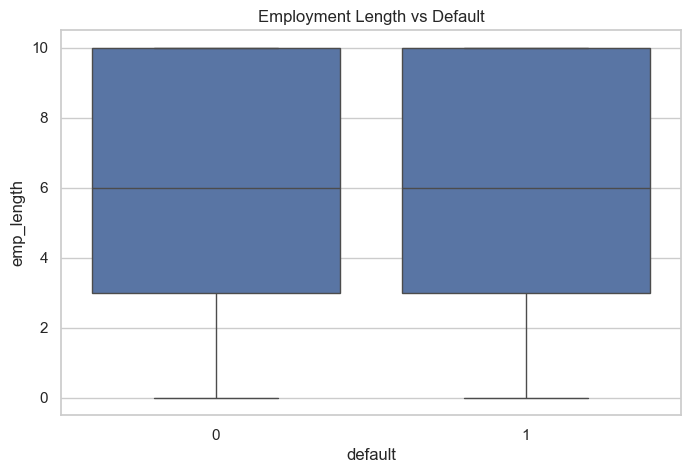

In [74]:
# Stage 5 — Exploratory Data Analysis (EDA): Step-3
# Bivariate Analysis

# Default Rate by Loan Grade
plt.figure(figsize=(8,5))
sns.barplot(x='grade', y='default', data=df)
plt.title("Default Rate by Loan Grade")
plt.show()

# Loan Amount vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x='default', y='loan_amnt', data=df)
plt.title("Loan Amount vs Default")
plt.show()

# Annual Income vs Default
plt.figure(figsize=(8,5))       
sns.boxplot(x='default', y='annual_inc', data=df)
plt.title("Annual Income vs Default")   
plt.show()

# Interest Rate vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x='default', y='int_rate', data=df)
plt.title("Interest Rate vs Default")
plt.show()

# DTI vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x='default', y='dti', data=df)  
plt.title("DTI vs Default")
plt.show()

# Employment Length vs Default
plt.figure(figsize=(8,5))
sns.boxplot(x='default', y='emp_length', data=df)       
plt.title("Employment Length vs Default")
plt.show()


**Insights**
Higher grades (E, F, G) → higher default

Lower grades (A, B) → safer loans

Higher interest → higher risk

Higher DTI → more financial stress → higher default

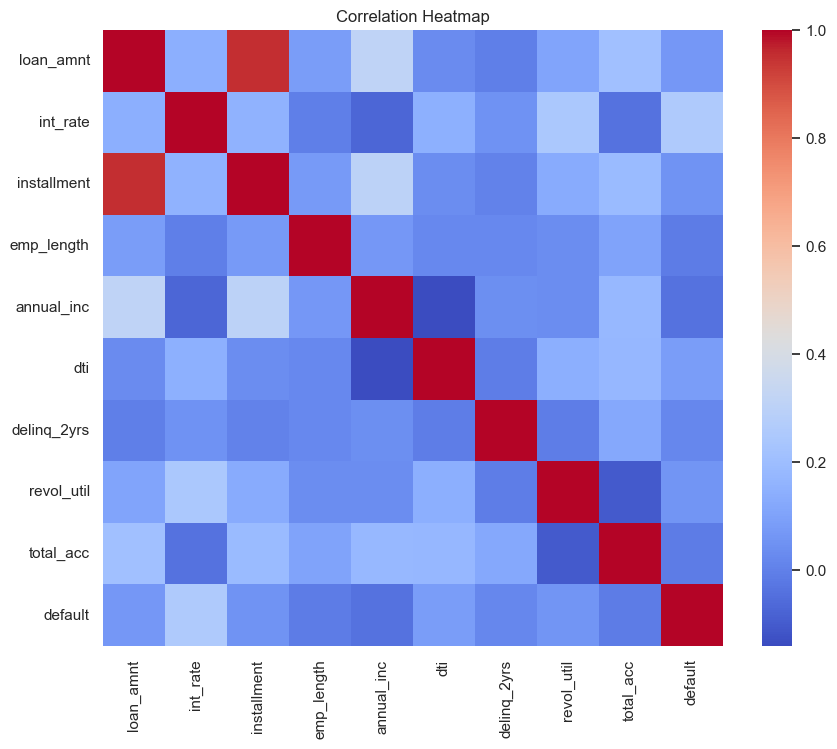

In [81]:
# Stage 5 — Exploratory Data Analysis (EDA): Step-4
# Correlation heatmap
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

**Insights**
Interest rate shows positive correlation with default → higher interest loans are riskier

DTI has moderate positive correlation → financially stressed borrowers default more

Loan amount has weak correlation → not a strong predictor alone

### Insights from Correlation Heatmap

- Interest rate shows a positive correlation with default, indicating that higher-risk borrowers tend to default more.
- Debt-to-income ratio (DTI) also shows a positive relationship with default, suggesting financially stressed individuals are more likely to default.
- Annual income shows a slight negative correlation, meaning higher income borrowers are less likely to default.
- Loan amount has very weak correlation with default, indicating it is not a strong standalone predictor.
- Overall, no single feature strongly predicts default, suggesting that a combination of factors influences loan risk.